# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [5]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/praxideswanyoike/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [6]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [7]:
def load_har_data(root_dir="UCI HAR Dataset"):
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(int) - 1

    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt")).astype(int) - 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Number of input features:", num_features)
print("Number of classes:", num_classes)
 

X_train shape: (7352, 561)
X_test shape : (2947, 561)
Number of input features: 561
Number of classes: 6


## 4. Quick Inspection

In [8]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#
label_counts = pd.Series(y_train).value_counts().sort_index()

dataset_summary = pd.DataFrame({
    "Class Index": list(range(num_classes)),
    "Class Name": class_names,
    "Training Samples": label_counts.values,
})

dataset_summary

,Class Index,Class Name,Training Samples
0,0,WALKING,1226
1,1,WALKING_UPSTAIRS,1073
2,2,WALKING_DOWNSTAIRS,986
3,3,SITTING,1286
4,4,STANDING,1374
5,5,LAYING,1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [12]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    inputs = keras.Input(shape=(input_dim,), name = "features")
    x = layers.Dense (256, activation = "relu")(inputs)
    x = layers.Dense(128, activation = "relu")(x)
    x = layers.Dense(64, activation = "relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name = "baseline_dnn")

    model.compile (optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
                    loss = "sparse_categorical_crossentropy",
                    metrics = ["accuracy"],)
    return model
    


baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "baseline_dnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 features (InputLayer)       [(None, 561)]             0         
                                                                 
 dense_7 (Dense)             (None, 256)               143872    
                                                                 
 dense_8 (Dense)             (None, 128)               32896     
                                                                 
 dense_9 (Dense)             (None, 64)                8256      
                                                                 
 dense_10 (Dense)            (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [14]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
history_baseline = baseline_model.fit (
    X_train,
    y_train,
    validation_split = .2,
    epochs = 40,
    batch_size = 64,
    callbacks = callbacks,
    verbose = 1
)



Epoch 1/40
92/92 [==============================] - 0s 1ms/step - loss: 0.5367 - accuracy: 0.7825 - val_loss: 0.1918 - val_accuracy: 0.9252
Epoch 2/40
92/92 [==============================] - 0s 899us/step - loss: 0.1643 - accuracy: 0.9367 - val_loss: 0.1275 - val_accuracy: 0.9436
Epoch 3/40
92/92 [==============================] - 0s 895us/step - loss: 0.1126 - accuracy: 0.9563 - val_loss: 0.3896 - val_accuracy: 0.8525
Epoch 4/40
92/92 [==============================] - 0s 883us/step - loss: 0.1048 - accuracy: 0.9589 - val_loss: 0.1576 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 872us/step - loss: 0.0778 - accuracy: 0.9689 - val_loss: 0.1950 - val_accuracy: 0.9239
Epoch 6/40
92/92 [==============================] - 0s 872us/step - loss: 0.0715 - accuracy: 0.9719 - val_loss: 0.1829 - val_accuracy: 0.9334
Epoch 7/40
92/92 [==============================] - 0s 886us/step - loss: 0.0609 - accuracy: 0.9779 - val_loss: 0.1316 - val_accuracy: 0.9490
Epoch 8/

### Training Curves

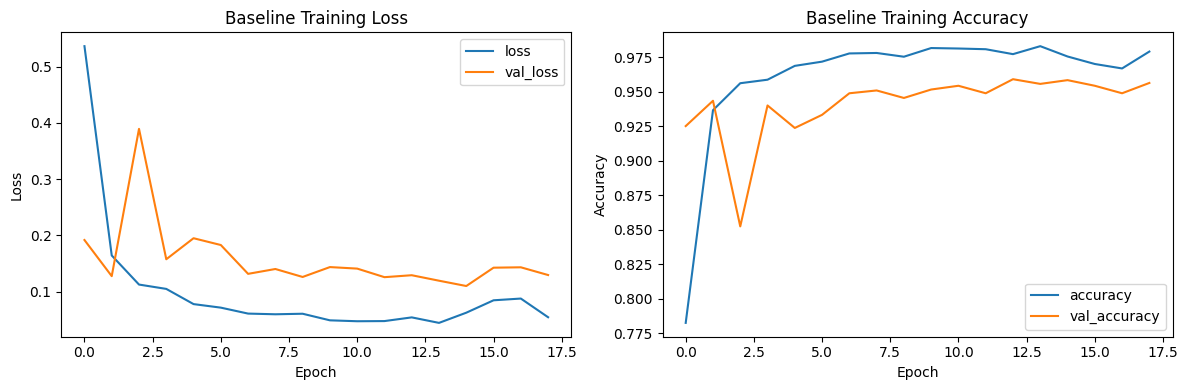

In [15]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#
history_baseline_df = pd.DataFrame(history_baseline.history)


fig, axes = plt.subplots(1, 2, figsize = (12,4))
history_baseline_df [["loss", "val_loss"]].plot(ax = axes[0], title="Baseline Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")


history_baseline_df[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Baseline Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")


plt.tight_layout()
plt.show()


## 6. Evaluate the Baseline Keras Model

93/93 [==============================] - 0s 329us/step
Test Accuracy :  0.9446895147607737
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       496
           1       0.92      0.95      0.94       471
           2       0.97      0.91      0.94       420
           3       0.96      0.84      0.90       491
           4       0.87      0.97      0.92       532
           5       1.00      1.00      1.00       537

    accuracy                           0.94      2947
   macro avg       0.95      0.94      0.94      2947
weighted avg       0.95      0.94      0.94      2947



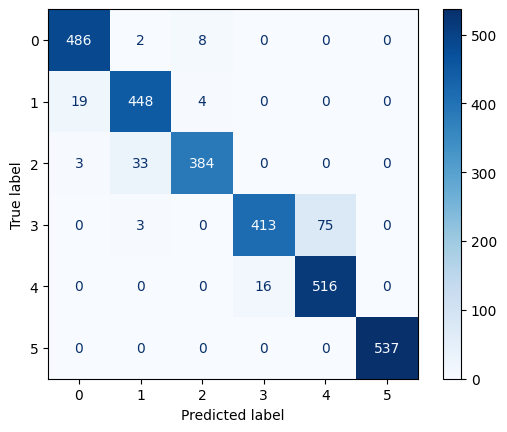

In [16]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_pred_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Test Accuracy : ", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred,cmap="Blues")
plt.show()


# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [113]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] == np.int8:
            x = np.round(x/input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round (x / input_scale + input_zero_point).astype(np.uint8)
        else: 
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--#
        if (output_details["dtype"] == np.int8 or output_details["dtype"] == np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

    # <-- Enter your code here <--#

def get_size_kb(path):
    return os.path.getsize(path)/1024.0

def make_result_row(model_name, path, accuracy):
    return {
        "model": model_name,
        "file" : path,
        "size_kb": round(get_size_kb(path), 2),
        "accuracy": round(float(accuracy), 4)
    }


## 8. Convert the Baseline Model to TensorFlow Lite

In [114]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.
baseline_tflite = convert_to_tflite_fp32(baseline_model)
baseline_size_kb = save_binary_model(baseline_tflite, "baseline_fp32.tflite")
baseline_acc, _ = evaluate_tflite_model(baseline_tflite, X_test, y_test)
# <-- Enter your code here <--#8


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpt7p59sy5/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpt7p59sy5/assets
2026-04-22 18:01:00.001640: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:01:00.002161: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:01:00.003032: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpt7p59sy5
2026-04-22 18:01:00.003398: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:01:00.003401: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpt7p59sy5
2026-04-22 18:01:00.009258: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:01:00.059576: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [115]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#

steps_per_epoch = int (np.ceil((.8 * len(X_train)) / batch_size))
    
pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity = .20,
        final_sparsity = .85, 
        begin_step = 0,
        end_step = steps_per_epoch * pruning_epochs
    )
}
    
# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
base_model_for_pruning = build_baseline_model(num_features, num_classes)
pruned_model = prune_low_magnitude(base_model_for_pruning, **pruning_params)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#

pruned_model.compile (
    optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)


history_pruned = pruned_model.fit (
    X_train,
    y_train, 
    validation_split = .2,
    epochs = pruning_epochs, 
    batch_size = batch_size,
    callbacks = pruning_callbacks,
    verbose = 1,
)


Epoch 1/12
92/92 [==============================] - 1s 2ms/step - loss: 0.5127 - accuracy: 0.7977 - val_loss: 0.2069 - val_accuracy: 0.9225
Epoch 2/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1933 - accuracy: 0.9250 - val_loss: 0.2020 - val_accuracy: 0.9191
Epoch 3/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1418 - accuracy: 0.9459 - val_loss: 0.1661 - val_accuracy: 0.9307
Epoch 4/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1018 - accuracy: 0.9655 - val_loss: 0.1416 - val_accuracy: 0.9381
Epoch 5/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1708 - accuracy: 0.9424 - val_loss: 0.1304 - val_accuracy: 0.9415
Epoch 6/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1356 - accuracy: 0.9583 - val_loss: 0.1715 - val_accuracy: 0.9334
Epoch 7/12
92/92 [==============================] - 0s 1ms/step - loss: 0.1893 - accuracy: 0.9376 - val_loss: 0.2104 - val_accuracy: 0.9259
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [116]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#
pruned_fp32_tflite = tf.lite.TFLiteConverter.from_keras_model(pruned_model).convert()

pruned_fp32_size = save_binary_model(pruned_fp32_tflite, "pruned_model_with_fp32.tflite")
pruned_fp32_acc, pruned_fp32_y_pred = evaluate_tflite_model(pruned_fp32_tflite, X_test, y_test)

stripped_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size = save_binary_model(stripped_sparse_tflite, "pruned_sparse.tflite")
stripped_sparse_acc, _ = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpa9zhl2a5/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpa9zhl2a5/assets
2026-04-22 18:01:04.514988: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:01:04.514998: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:01:04.515070: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpa9zhl2a5
2026-04-22 18:01:04.516015: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:01:04.516019: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpa9zhl2a5
2026-04-22 18:01:04.518579: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:01:04.539287: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmptanqya3f/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmptanqya3f/assets
2026-04-22 18:01:04.936297: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:01:04.936305: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:01:04.936370: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmptanqya3f
2026-04-22 18:01:04.936609: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:01:04.936612: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmptanqya3f
2026-04-22 18:01:04.937140: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:01:04.943271: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 11. Part I Comparison: Accuracy and Model Size

In [117]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#
part1_rows = []
baseline_tflite_acc, _ = evaluate_tflite_model (baseline_tflite, X_test, y_test)
pruned_with_mask_acc, _ = evaluate_tflite_model (pruned_fp32_tflite, X_test, y_test)
pruned_sparse_acc, pruned_sparse_y_pred = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)

part1_rows.append(make_result_row ("Baseline TFlite", "baseline_fp32.tflite", baseline_tflite_acc))
part1_rows.append(make_result_row ("Pruned TFlite (with mask)", "pruned_model_with_fp32.tflite" , pruned_with_mask_acc))
part1_rows.append(make_result_row ("Pruned Sparse TFlite" , "pruned_sparse.tflite",  pruned_sparse_acc))

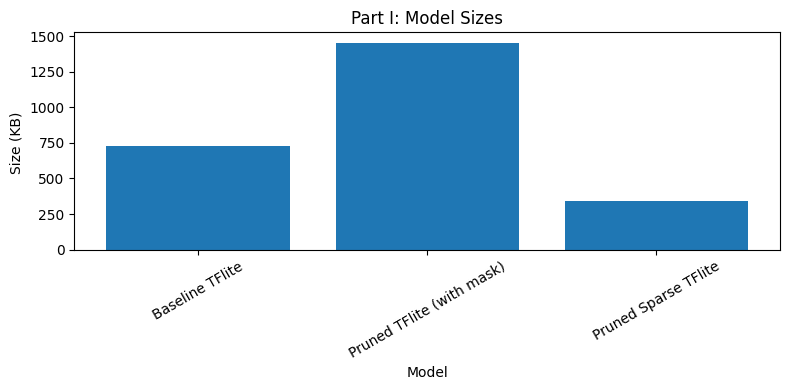

In [118]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#
part1_results = pd.DataFrame(part1_rows)
part1_plot_df = part1_results.copy()

plt.figure(figsize=(8, 4))
plt.bar (part1_plot_df["model"], part1_plot_df["size_kb"])
plt.ylabel("Size (KB) ")
plt.title("Part I: Model Sizes")
plt.xlabel("Model")
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

Classification Report for Stripped Sparse TFLite Model:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       496
           1       0.95      0.92      0.93       471
           2       0.90      0.96      0.93       420
           3       0.94      0.84      0.88       491
           4       0.84      0.95      0.89       532
           5       1.00      0.97      0.99       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



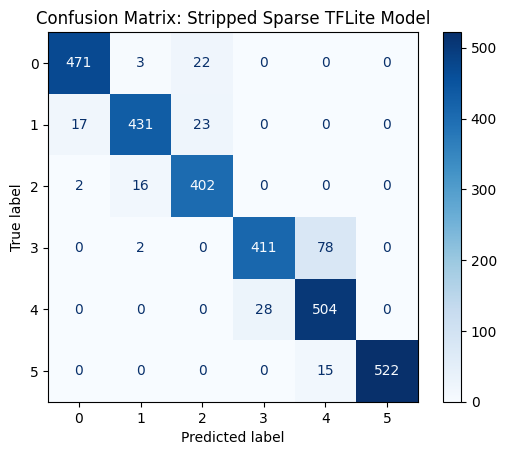

In [119]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#
print ("Classification Report for Stripped Sparse TFLite Model:")
print (classification_report (y_test, pruned_sparse_y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, pruned_sparse_y_pred, cmap = "Blues")
plt.title("Confusion Matrix: Stripped Sparse TFLite Model")
plt.show()


# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [120]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_with_mask_float16_tflite = converter.convert()

pruned_with_mask_float16_size = save_binary_model(
    pruned_with_mask_float16_tflite,
    "pruned_model_with_mask_float16.tflite"
)
pruned_with_mask_float16_acc, pruned_with_mask_float16_y_pred = evaluate_tflite_model (pruned_with_mask_float16_tflite, X_test, y_test)


converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]
pruned_sparse_float16_tflite = converter.convert()

pruned_sparse_float16_size = save_binary_model(pruned_sparse_float16_tflite, "pruned_model_sparse_float16.tflite")
pruned_sparse_float16_acc, pruned_sparse_float16_y_pred = evaluate_tflite_model(
    pruned_sparse_float16_tflite, X_test, y_test
)


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpdgqtpds5/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpdgqtpds5/assets
2026-04-22 18:01:13.803058: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:01:13.803067: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:01:13.803140: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpdgqtpds5
2026-04-22 18:01:13.804024: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:01:13.804028: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmpdgqtpds5
2026-04-22 18:01:13.806501: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:01:13.826953: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmplrbumj3g/assets


INFO:tensorflow:Assets written to: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmplrbumj3g/assets
2026-04-22 18:01:14.233060: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-22 18:01:14.233069: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-22 18:01:14.233137: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmplrbumj3g
2026-04-22 18:01:14.233372: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-22 18:01:14.233375: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/mj/y1x2tmfn7nz93rgy_fnv55ym0000gp/T/tmplrbumj3g
2026-04-22 18:01:14.233913: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-22 18:01:14.239979: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

## 12. Part II Comparison: Accuracy and Model Size

In [121]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#

part2_rows = []


pruned_fp32_acc, _ = evaluate_tflite_model(pruned_fp32_tflite, X_test, y_test)
stripped_sparse_fp32_acc, _ = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)
pruned_with_mask_float16_acc, _ = evaluate_tflite_model(pruned_with_mask_float16_tflite, X_test, y_test)
pruned_sparse_float16_acc, _ = evaluate_tflite_model(pruned_sparse_float16_tflite, X_test, y_test)

part2_rows.append(make_result_row ("Pruned fp32", "pruned_model_with_fp32.tflite", pruned_fp32_acc))
part2_rows.append(make_result_row("Pruned sparse fp32", "pruned_sparse.tflite",stripped_sparse_acc))
part2_rows.append(make_result_row ("Pruned float16", "pruned_model_with_mask_float16.tflite", pruned_with_mask_float16_acc))
part2_rows.append(make_result_row ("Pruned sparse float 16", "pruned_model_sparse_float16.tflite", pruned_sparse_float16_acc))


            

part2_results = pd.DataFrame(part2_rows)
part2_results



,model,file,size_kb,accuracy
0,Pruned fp32,pruned_model_with_fp32.tflite,1454.26,0.9301
1,Pruned sparse fp32,pruned_sparse.tflite,338.91,0.9301
2,Pruned float16,pruned_model_with_mask_float16.tflite,732.67,0.9301
3,Pruned sparse float 16,pruned_model_sparse_float16.tflite,223.75,0.9301


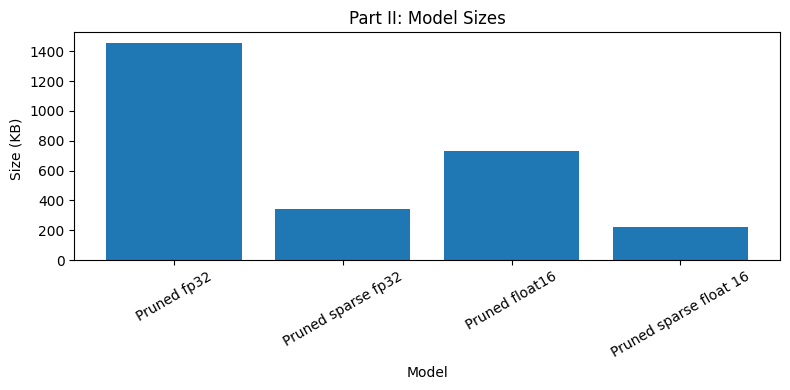

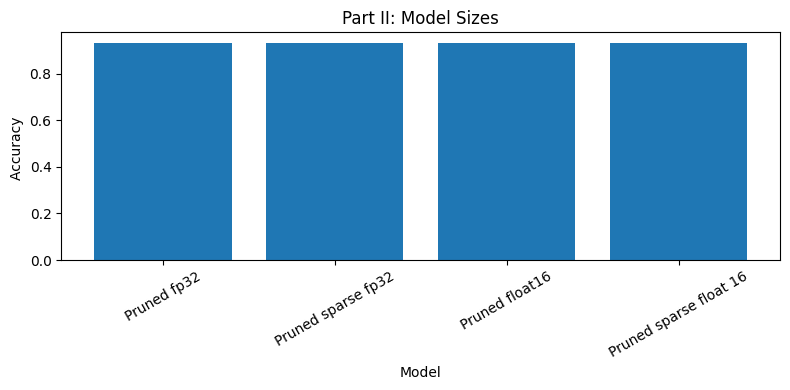

In [122]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#

part2_plot_df = part2_results.copy()

plt.figure(figsize=(8, 4))
plt.bar (part2_plot_df["model"], part2_plot_df["size_kb"])
plt.ylabel("Size (KB) ")
plt.title("Part II: Model Sizes")
plt.xlabel("Model")
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.bar (part2_plot_df["model"], part2_plot_df["accuracy"])
plt.ylabel("Accuracy ")
plt.title("Part II: Model Sizes")
plt.xlabel("Model")
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

Classification Report: 
              precision    recall  f1-score   support

           0       0.17      1.00      0.29       496
           1       0.00      0.00      0.00       471
           2       0.00      0.00      0.00       420
           3       0.00      0.00      0.00       491
           4       0.00      0.00      0.00       532
           5       0.00      0.00      0.00       537

    accuracy                           0.17      2947
   macro avg       0.03      0.17      0.05      2947
weighted avg       0.03      0.17      0.05      2947



/Users/praxideswanyoike/ai/projects/tinyml-arduino/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/praxideswanyoike/ai/projects/tinyml-arduino/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/praxideswanyoike/ai/projects/tinyml-arduino/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

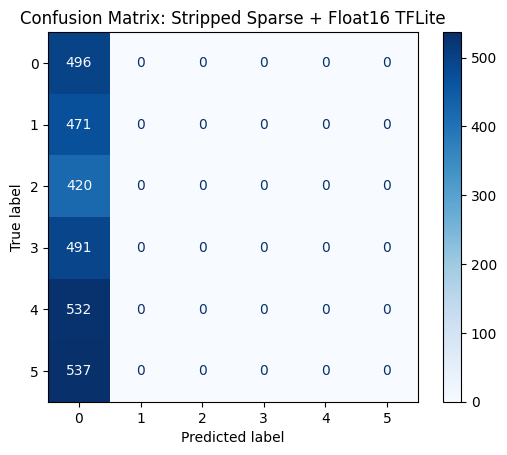

In [112]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#
print("Classification Report: " )
print (classification_report(y_test, pruned_sparse_float16_y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, pruned_sparse_float16_y_pred, cmap = "Blues")
plt.title("Confusion Matrix: Stripped Sparse + Float16 TFLite")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
   No, pruning alone did not reduce the TensorFlow Lite filse size with the wrappers still attatched. 
2. Why does `strip_pruning(...)` matter before export?
   It mattered because it got rid of unnecessary wrappers to be more easily compressed and exported.
3. Which model had the smallest file size in this notebook?
   The pruned sparse float16 had the smallest file size. 
4. Did float16 quantization noticeably change the test accuracy?
   No, the float16 quantization did not noticeably change the test accuracy.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
    I would choose the float16 model because it has a small model size and it keep s a high accuracy.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
